# 1. Load dataset

In [ ]:
import os
import pandas as pd
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
# Project folder:
DRIVE_BASE = '/content/drive/MyDrive/deep_learning'

# Dataset:
DRIVE_FILE_PATH = f'{DRIVE_BASE}/spotify_dataset.csv'

# Checkpoints BERT + audio:
ckpt_dir_bert_fusion = f'{DRIVE_BASE}/checkpoints_bert_fusion'

# Checkpoints BERT only:
ckpt_dir_bert_only = f'{DRIVE_BASE}/checkpoints_bert_only'

In [ ]:
if os.path.exists(DRIVE_FILE_PATH):
    df = pd.read_csv(DRIVE_FILE_PATH)
    print(df.columns.tolist())
else:
    print(f"File not found at: {DRIVE_FILE_PATH}")
    print("Training from scratch or creating a new dataframe is required.")

Mounted at /content/drive
['Artist(s)', 'song', 'text', 'Length', 'emotion', 'Genre', 'Album', 'Release Date', 'Key', 'Tempo', 'Loudness (db)', 'Time signature', 'Explicit', 'Popularity', 'Energy', 'Danceability', 'Positiveness', 'Speechiness', 'Liveness', 'Acousticness', 'Instrumentalness', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine', 'Similar Artist 1', 'Similar Song 1', 'Similarity Score 1', 'Similar Artist 2', 'Similar Song 2', 'Similarity Score 2', 'Similar Artist 3', 'Similar Song 3', 'Similarity Score 3']


In [80]:
print(f"Dataset shape (rows, cols): {df.shape}")

print(df.info())

df.head()

Dataset shape (rows, cols): (551443, 39)
<class 'pandas.DataFrame'>
RangeIndex: 551443 entries, 0 to 551442
Data columns (total 39 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   Artist(s)                       551443 non-null  str    
 1   song                            551427 non-null  str    
 2   text                            551443 non-null  str    
 3   Length                          551443 non-null  str    
 4   emotion                         551443 non-null  str    
 5   Genre                           551443 non-null  str    
 6   Album                           551391 non-null  str    
 7   Release Date                    551443 non-null  str    
 8   Key                             551443 non-null  str    
 9   Tempo                           551443 non-null  int64  
 10  Loudness (db)                   551443 non-null  str    
 11  Time signature                  551435 non-null 

,Artist(s),song,text,Length,emotion,Genre,Album,Release Date,Key,Tempo,...,Good for Morning Routine,Similar Artist 1,Similar Song 1,Similarity Score 1,Similar Artist 2,Similar Song 2,Similarity Score 2,Similar Artist 3,Similar Song 3,Similarity Score 3
0,!!!,Even When the Waters Cold,Friends told her she was better off at the bot...,03:47,sadness,hip hop,Thr!!!er,29th April 2013,D min,105,...,0,Corey Smith,If I Could Do It Again,0.986061,Toby Keith,Drinks After Work,0.983719,Space,Neighbourhood,0.983236
1,!!!,One Girl / One Boy,"Well I heard it, playing soft From a drunken b...",04:03,sadness,hip hop,Thr!!!er,29th April 2013,A# min,117,...,0,Hiroyuki Sawano,BRE@TH//LESS,0.995409,When In Rome,Heaven Knows,0.990905,Justice Crew,Everybody,0.984483
2,!!!,Pardon My Freedom,"Oh my god, did I just say that out loud? Shoul...",05:51,joy,hip hop,Louden Up Now,8th June 2004,A Maj,121,...,0,Ricky Dillard,More Abundantly Medley Live,0.993176,Juliet,Avalon,0.965147,The Jacksons,Lovely One,0.956752
3,!!!,Ooo,[Verse 1] Remember when I called you on the te...,03:44,joy,hip hop,As If,16th October 2015,A min,122,...,0,Eric Clapton,Man Overboard,0.992749,Roxette,Don't Believe In Accidents,0.991494,Tiwa Savage,My Darlin,0.990381
4,!!!,Freedom 15,[Verse 1] Calling me like I got something to s...,06:00,joy,hip hop,As If,16th October 2015,F min,123,...,0,Cibo Matto,Lint Of Love,0.981610,Barrington Levy,Better Than Gold,0.981524,Freestyle,Its Automatic,0.981415


# 2. Label distribution and one-hot encoding

Total number of labels : 22
                                Number of Tracks  Share (%)
joy                                       209009  37.902195
sadness                                   171078  31.023696
anger                                     109678  19.889272
Good for Exercise                         103304  18.733396
Good for Work/Study                        41320   7.493068
Good for Morning Routine                   36514   6.621537
Good for Party                             34084   6.180875
Good for Driving                           31872   5.779745
Good for Running                           29691   5.384237
fear                                       28097   5.095178
love                                       27963   5.070878
Good for Relaxation/Meditation             16969   3.077199
Good for Yoga/Stretching                   11847   2.148363
Good for Social Gatherings                  6757   1.225331
surprise                                    5592   1.014067
True        

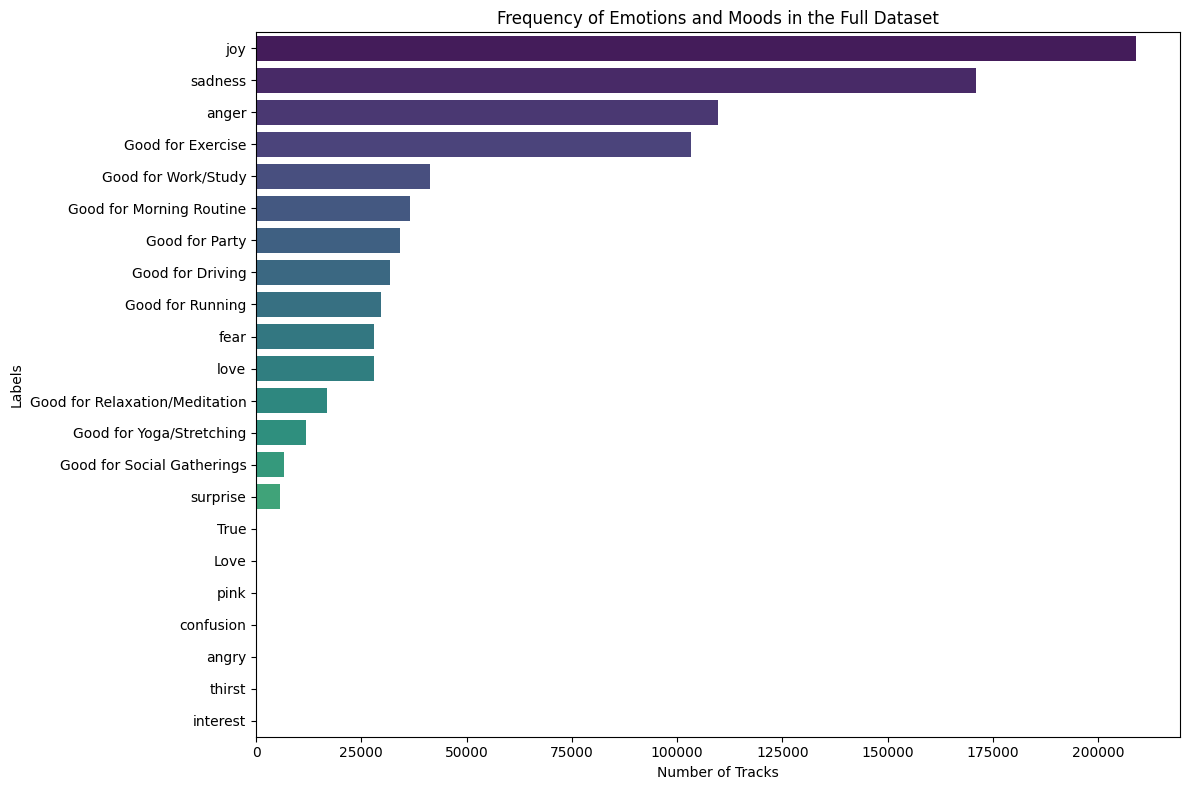

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# One hot encoding
df_emotions_encoded = pd.get_dummies(df['emotion'], prefix='', prefix_sep='').astype(int)

emotion_labels = list(df_emotions_encoded.columns)

activity_labels = [
    'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation',
    'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching',
    'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine'
]

df_extended = pd.concat([df, df_emotions_encoded], axis=1)

all_labels = emotion_labels + activity_labels

print(f"Total number of labels : {len(all_labels)}")

label_counts = df_extended[all_labels].sum().sort_values(ascending=False)
label_percentages = (df_extended[all_labels].sum() / len(df_extended) * 100).sort_values(ascending=False)

distribution_df = pd.DataFrame({'Number of Tracks': label_counts, 'Share (%)': label_percentages})
print(distribution_df)

plt.figure(figsize=(12, 8))
sns.barplot(
    x=label_counts.values,
    y=label_counts.index,
    hue=label_counts.index,
    palette='viridis',
    legend=False
)
plt.title('Frequency of Emotions and Moods in the Full Dataset')
plt.xlabel('Number of Tracks')
plt.ylabel('Labels')
plt.tight_layout()
plt.show()

# 3. Data cleaning
Remove very infrequent labels and merge the labels "anger" with "angry", and "love" with "Love".

In [4]:
emotion_mapping = {
    'Love': 'love',
    'angry': 'anger',
}

df['emotion'] = df['emotion'].replace(emotion_mapping)

df_emotions_encoded = pd.get_dummies(df['emotion'], prefix='', prefix_sep='').astype(int)

df_extended = pd.concat([df, df_emotions_encoded], axis=1)

emotion_labels = list(df_emotions_encoded.columns)
all_labels = emotion_labels + activity_labels
print(all_labels)

['True', 'anger', 'confusion', 'fear', 'interest', 'joy', 'love', 'pink', 'sadness', 'surprise', 'thirst', 'Good for Party', 'Good for Work/Study', 'Good for Relaxation/Meditation', 'Good for Exercise', 'Good for Running', 'Good for Yoga/Stretching', 'Good for Driving', 'Good for Social Gatherings', 'Good for Morning Routine']


In [5]:
CUTOFF_THRESHOLD = 50

label_sums = df_extended[all_labels].sum()

target_columns = label_sums[label_sums >= CUTOFF_THRESHOLD].index.tolist()

dropped_labels = sorted(set(all_labels) - set(target_columns))

print(f"Dropped labels ({len(dropped_labels)}): {dropped_labels}")
print(f"Remaining labels: {len(target_columns)}")

label_counts = df_extended[target_columns].sum().sort_values(ascending=False)
label_percentages = (label_counts / len(df_extended) * 100)

distribution_df = pd.DataFrame({
    'Number of Tracks': label_counts,
    'Share (%)': label_percentages
})

print(distribution_df)

Dropped labels (5): ['True', 'confusion', 'interest', 'pink', 'thirst']
Remaining labels: 15
                                Number of Tracks  Share (%)
joy                                       209009  37.902195
sadness                                   171078  31.023696
anger                                     109679  19.889454
Good for Exercise                         103304  18.733396
Good for Work/Study                        41320   7.493068
Good for Morning Routine                   36514   6.621537
Good for Party                             34084   6.180875
Good for Driving                           31872   5.779745
Good for Running                           29691   5.384237
fear                                       28097   5.095178
love                                       27966   5.071422
Good for Relaxation/Meditation             16969   3.077199
Good for Yoga/Stretching                   11847   2.148363
Good for Social Gatherings                  6757   1.225331
surpris

# 4. Get random sample to speed expreimental phase

In [ ]:
SAMPLE_SIZE = 50000

df_sample = df_extended.sample(n=SAMPLE_SIZE, random_state=42).copy()

print(f"Sample shape: {df_sample.shape}")

sample_percentages = (df_sample[target_columns].sum() / len(df_sample) * 100)
print("\nPercentage of each label in the sample:")
print(sample_percentages.round(2).sort_values(ascending=False))

df_sample.to_csv(f'{DRIVE_BASE}/df_sample.csv', index=False)
print("Saved to df_sample.csv")

Sample shape: (50000, 50)

Percentage of each label in the sample:
joy                               37.58
sadness                           31.01
anger                             19.97
Good for Exercise                 18.76
Good for Work/Study                7.44
Good for Morning Routine           6.74
Good for Party                     6.24
Good for Driving                   5.77
Good for Running                   5.42
love                               5.21
fear                               5.15
Good for Relaxation/Meditation     3.08
Good for Yoga/Stretching           2.12
Good for Social Gatherings         1.20
surprise                           1.08
dtype: float64
Saved to df_sample.csv


In [7]:
import re


def get_lyrics_cleaned(text):
    if not isinstance(text, str):
        return ""

    text = text.lower().strip()

    text = re.sub(r'[a-z0-9]+/[a-z0-9]+', '', text)

    if text.startswith("lyrics "):
        text = text[len("lyrics "):].strip()
    if text.startswith("written by "):
        text = text[len("written by "):].strip()

    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'\(.*?\)', '', text)

    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

df_sample['cleaned_text'] = df_sample['text'].astype(str).apply(get_lyrics_cleaned)

print("Before cleaning:")
print(df_sample['text'].iloc[:5])
print("\nAfter cleaning:")
print(df_sample['cleaned_text'].iloc[:5])

Before cleaning:
420798    Lyrics/Music Yellen/Pokrass Why are grown up p...
447960    Sharing's good, sharing's fine    But no one w...
119751    [Intro] Let it go, let it go Can’t hold it bac...
83902     [Intro: Sav'O] (Madara) J'S, J'S  [Verse 1: Sa...
318397    [Produced by: THEMPeople]  [Intro: Sample] "Lo...
Name: text, dtype: object

After cleaning:
420798    why are grown up peoples faces wrinkled like a...
447960    sharings good sharings fine but no one wants t...
119751    let it go let it go cant hold it back anymore ...
83902     js js if your friend gets packed and you pack ...
318397    love you know what do you know about love what...
Name: cleaned_text, dtype: object


# 5. Train, val and test split

In [8]:
from sklearn.model_selection import train_test_split

X = df_sample.drop(columns=target_columns)
y = df_sample[target_columns]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]} rows (80%)")
print(f"Val: {X_val.shape[0]} rows (10%)")
print(f"Test: {X_test.shape[0]} rows (10%)")

Train: 40000 rows (80%)
Val: 5000 rows (10%)
Test: 5000 rows (10%)


# 6. Baseline model - TF-IDF + Logistic Regression

The first model serves as a baseline for comparison with more advanced neural architectures.

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report


In [10]:
# Build TF-IDF matrix on training lyrics
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train['cleaned_text'])
X_val_tfidf = tfidf.transform(X_val['cleaned_text'])
X_test_tfidf = tfidf.transform(X_test['cleaned_text'])

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")

TF-IDF matrix shape (train): (40000, 20000)


In [11]:
# Train One-vs-Rest Logistic Regression classifier
lr_clf = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42),
    n_jobs=-1
)

lr_clf.fit(X_train_tfidf, y_train)

y_val_pred_lr = lr_clf.predict(X_val_tfidf)

f1_micro_lr = f1_score(y_val, y_val_pred_lr, average='micro', zero_division=0)
f1_macro_lr = f1_score(y_val, y_val_pred_lr, average='macro', zero_division=0)

print(f"[LR baseline] Validation micro-F1 : {f1_micro_lr:.4f}")
print(f"[LR baseline] Validation macro-F1 : {f1_macro_lr:.4f}")
print()
print(classification_report(y_val, y_val_pred_lr, target_names=target_columns, zero_division=0))

[LR baseline] Validation micro-F1 : 0.3740
[LR baseline] Validation macro-F1 : 0.1345

                                precision    recall  f1-score   support

                         anger       0.72      0.28      0.40      1015
                          fear       0.44      0.01      0.03       293
                           joy       0.71      0.52      0.60      1838
                          love       0.86      0.05      0.09       264
                       sadness       0.73      0.43      0.54      1542
                      surprise       1.00      0.04      0.08        48
                Good for Party       1.00      0.05      0.10       311
           Good for Work/Study       1.00      0.01      0.01       382
Good for Relaxation/Meditation       0.00      0.00      0.00       163
             Good for Exercise       0.67      0.04      0.07       930
              Good for Running       1.00      0.02      0.04       270
      Good for Yoga/Stretching       0.00      0

# 7. BiLSTM

In [12]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter

PAD_TOKEN, UNK_TOKEN = '<PAD>', '<UNK>'

def build_vocab(texts, max_vocab=30000, min_freq=2):
    counter = Counter(tok for text in texts for tok in text.split())
    vocab = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.most_common(max_vocab):
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

vocab = build_vocab(X_train['cleaned_text'])
print(f"Vocabulary size (with special tokens): {len(vocab):,}")

NUM_LABELS = len(target_columns)
MAX_LEN = 100

class LyricsDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=MAX_LEN):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True).values.astype('float32')
        self.vocab = vocab
        self.max_len = max_len

    def encode(self, text):
        ids = [self.vocab.get(tok, self.vocab[UNK_TOKEN]) for tok in text.split()[:self.max_len]]
        ids += [self.vocab[PAD_TOKEN]] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long)

    def __len__(self):  return len(self.texts)
    def __getitem__(self, i):
        return self.encode(self.texts[i]), torch.tensor(self.labels[i])

train_ds = LyricsDataset(X_train['cleaned_text'], y_train, vocab)
val_ds = LyricsDataset(X_val['cleaned_text'], y_val, vocab)
test_ds = LyricsDataset(X_test['cleaned_text'], y_test, vocab)

BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Batches - train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}")

Vocabulary size (with special tokens): 30,002
Batches - train: 625 | val: 79 | test: 79


In [13]:
class LyricsLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=256,
                 num_layers=2, num_labels=NUM_LABELS, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_labels)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (h, _) = self.lstm(emb)
        feat = torch.cat([h[-2], h[-1]], dim=1)
        return self.classifier(self.dropout(feat))

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {DEVICE}")

lstm_model = LyricsLSTM(vocab_size=len(vocab)).to(DEVICE)
print(lstm_model)
total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

Using device: cuda
LyricsLSTM(
  (embedding): Embedding(30002, 128, padding_idx=0)
  (lstm): LSTM(128, 256, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=512, out_features=15, bias=True)
)

Trainable parameters: 6,215,439


In [ ]:
import numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

label_counts = y_train.sum(axis=0).values
pos_weight = torch.tensor((len(y_train) - label_counts) / label_counts, dtype=torch.float32).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5)

EPOCHS = 5 # CHWILOWO ZMNIEJSZONE
PATIENCE = 3
epochs_no_improve = 0
history = {'train_loss': [], 'val_loss': [], 'val_f1_micro': []}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    lstm_model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = lstm_model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    lstm_model.eval()
    val_loss = 0.0
    all_preds, all_labels_v = [], []
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            logits = lstm_model(X_batch)
            val_loss += criterion(logits, y_batch).item()
            preds = (torch.sigmoid(logits) > 0.3).cpu().numpy()
            all_preds.append(preds)
            all_labels_v.append(y_batch.cpu().numpy())
    val_loss /= len(val_loader)
    all_preds = np.vstack(all_preds)
    all_labels_v = np.vstack(all_labels_v)
    val_f1 = f1_score(all_labels_v, all_preds, average='micro', zero_division=0)

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1_micro'].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save(lstm_model.state_dict(), f'{DRIVE_BASE}/best_lstm.pt')
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_micro-F1: {val_f1:.4f}")

print(f"\nBest validation micro-F1: {best_val_f1:.4f}")

Epoch 01/5 | train_loss: 1.2350 | val_loss: 1.2345 | val_micro-F1: 0.1908
Epoch 02/5 | train_loss: 1.1939 | val_loss: 1.2202 | val_micro-F1: 0.2052
Epoch 03/5 | train_loss: 1.1437 | val_loss: 1.2075 | val_micro-F1: 0.2114
Epoch 04/5 | train_loss: 1.0819 | val_loss: 1.2240 | val_micro-F1: 0.2212
Epoch 05/5 | train_loss: 1.0056 | val_loss: 1.2873 | val_micro-F1: 0.2360

Best validation micro-F1: 0.2360


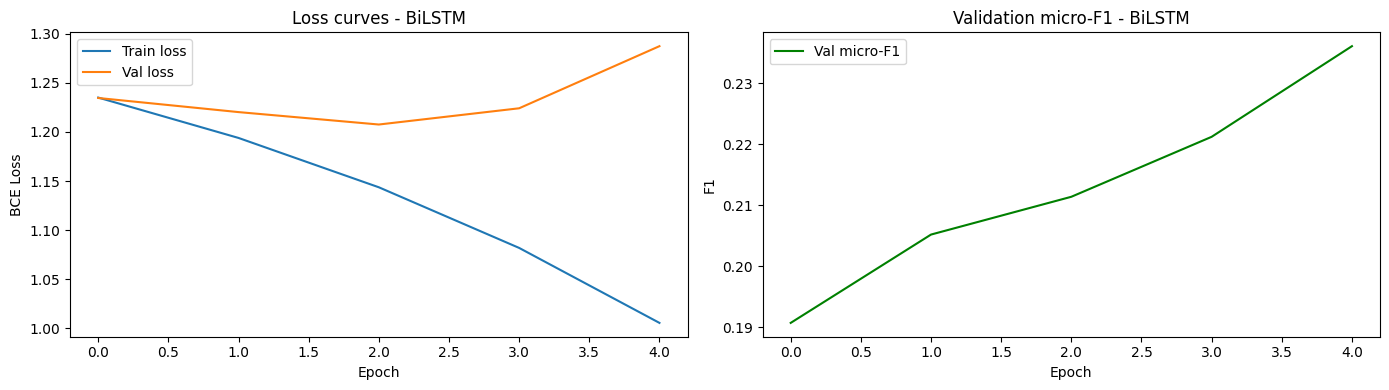

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='Train loss')
axes[0].plot(history['val_loss'], label='Val loss')
axes[0].set_title('Loss curves - BiLSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(history['val_f1_micro'], color='green', label='Val micro-F1')
axes[1].set_title('Validation micro-F1 - BiLSTM')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.show()

# 8. Baseline Models Comparison

                              Test micro-F1  Test macro-F1
Model                                                     
TF-IDF + Logistic Regression         0.3673         0.1244
BiLSTM                               0.2357         0.1926


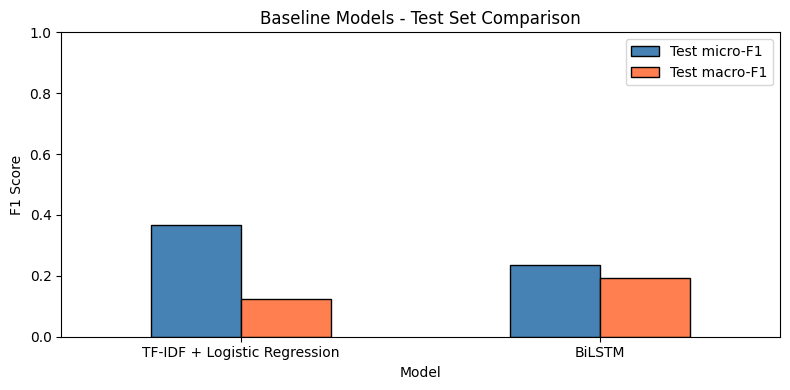

In [16]:
lstm_model.load_state_dict(torch.load('best_lstm.pt', map_location=DEVICE))
lstm_model.eval()

all_preds_lstm, all_labels_test = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = lstm_model(X_batch.to(DEVICE))
        preds = (torch.sigmoid(logits) > 0.3).cpu().numpy()
        all_preds_lstm.append(preds)
        all_labels_test.append(y_batch.numpy())

all_preds_lstm = np.vstack(all_preds_lstm)
all_labels_test_arr = np.vstack(all_labels_test)

y_test_pred_lr = lr_clf.predict(X_test_tfidf)

results = {
    'Model': ['TF-IDF + Logistic Regression', 'BiLSTM'],
    'Test micro-F1': [
        f1_score(y_test, y_test_pred_lr, average='micro', zero_division=0),
        f1_score(all_labels_test_arr, all_preds_lstm, average='micro', zero_division=0)
    ],
    'Test macro-F1': [
        f1_score(y_test, y_test_pred_lr, average='macro', zero_division=0),
        f1_score(all_labels_test_arr, all_preds_lstm, average='macro', zero_division=0)
    ]
}

results_df = pd.DataFrame(results).set_index('Model')
print(results_df.round(4))

results_df.plot(kind='bar', figsize=(8, 4), ylim=(0, 1), rot=0,
                color=['steelblue', 'coral'], edgecolor='black')
plt.title('Baseline Models - Test Set Comparison')
plt.ylabel('F1 Score')
plt.tight_layout()
plt.show()

# 9. BERT with audio features vs without

## 9.1 Optimizing BERT Sequence Length

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1033 > 512). Running this sequence through the model will result in indexing errors


count    2000.000000
mean      365.793000
std       260.686396
min        23.000000
25%       204.000000
50%       300.000000
75%       476.250000
max      5759.000000
Name: cleaned_text, dtype: float64

50th percentile: 300 tokenów
75th percentile: 476 tokenów
90th percentile: 680 tokenów
95th percentile: 801 tokenów
99th percentile: 1066 tokenów


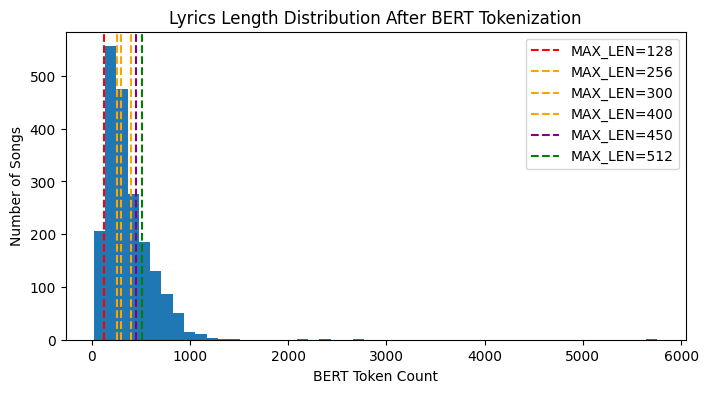


% of songs truncated at MAX_LEN=128: 91.3%
% of songs truncated at MAX_LEN=256: 60.8%
% of songs truncated at MAX_LEN=300: 49.8%
% of songs truncated at MAX_LEN=400: 33.8%
% of songs truncated at MAX_LEN=450: 27.8%
% of songs truncated at MAX_LEN=512: 21.8%


In [83]:
from transformers import BertTokenizer
tokenizer_check = BertTokenizer.from_pretrained('bert-base-uncased')

sample_for_check = X_train['cleaned_text'].sample(2000, random_state=42)
token_lengths = sample_for_check.apply(lambda t: len(tokenizer_check.encode(t, add_special_tokens=True)))

print(token_lengths.describe())
print()
for p in [50, 75, 90, 95, 99]:
    print(f'{p}th percentile: {int(np.percentile(token_lengths, p))} tokenów')

plt.figure(figsize=(8, 4))
plt.hist(token_lengths, bins=50)
plt.axvline(128, color='red', linestyle='--', label='MAX_LEN=128')
plt.axvline(256, color='orange', linestyle='--', label='MAX_LEN=256')
plt.axvline(300, color='orange', linestyle='--', label='MAX_LEN=300')
plt.axvline(400, color='orange', linestyle='--', label='MAX_LEN=400')
plt.axvline(450, color='purple', linestyle='--', label='MAX_LEN=450')
plt.axvline(512, color='green', linestyle='--', label='MAX_LEN=512')
plt.xlabel('BERT Token Count')
plt.ylabel('Number of Songs')
plt.title('Lyrics Length Distribution After BERT Tokenization')
plt.legend()
plt.show()

pct_truncated_128 = (token_lengths > 128).mean() * 100
pct_truncated_256 = (token_lengths > 256).mean() * 100
pct_truncated_300 = (token_lengths > 300).mean() * 100
pct_truncated_400 = (token_lengths > 400).mean() * 100
pct_truncated_450 = (token_lengths > 450).mean() * 100
pct_truncated_512 = (token_lengths > 512).mean() * 100

print(f'\n% of songs truncated at MAX_LEN=128: {pct_truncated_128:.1f}%')
print(f'% of songs truncated at MAX_LEN=256: {pct_truncated_256:.1f}%')
print(f'% of songs truncated at MAX_LEN=300: {pct_truncated_300:.1f}%')
print(f'% of songs truncated at MAX_LEN=400: {pct_truncated_400:.1f}%')
print(f'% of songs truncated at MAX_LEN=450: {pct_truncated_450:.1f}%')
print(f'% of songs truncated at MAX_LEN=512: {pct_truncated_512:.1f}%')

## 9.2 Extracting a Subset for Hyperparameter Tuning

In [18]:
df_sample_small = df_sample.sample(n=2000, random_state=42).copy()

X_small = df_sample_small.drop(columns=target_columns)
y_small = df_sample_small[target_columns]

X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    X_small, y_small, test_size=0.20, random_state=42
)
X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
    X_temp_s, y_temp_s, test_size=0.50, random_state=42
)

print(f"Train: {X_train_s.shape[0]} rows")
print(f"Val:   {X_val_s.shape[0]} rows")
print(f"Test:  {X_test_s.shape[0]} rows")

Train: 1600 rows
Val:   200 rows
Test:  200 rows


In [84]:
from transformers import BertModel, get_linear_schedule_with_warmup
from sklearn.preprocessing import StandardScaler

AUDIO_COLS = ['Energy', 'Danceability', 'Tempo', 'Loudness (db)', 'Positiveness']
NUM_AUDIO_FEATURES = len(AUDIO_COLS)

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

for split in (X_train, X_val, X_test, X_train_s, X_val_s, X_test_s):
    split['Loudness (db)'] = (
        split['Loudness (db)']
        .astype(str)
        .str.replace('db', '', regex=False)
        .str.strip()
        .astype(float)
    )

audio_scaler = StandardScaler()
A_train   = audio_scaler.fit_transform(X_train[AUDIO_COLS].values)
A_val     = audio_scaler.transform(X_val[AUDIO_COLS].values)
A_test    = audio_scaler.transform(X_test[AUDIO_COLS].values)

audio_scaler_s = StandardScaler()
A_train_s = audio_scaler_s.fit_transform(X_train_s[AUDIO_COLS].values)
A_val_s   = audio_scaler_s.transform(X_val_s[AUDIO_COLS].values)

print(f'Audio features: {AUDIO_COLS}')
print(f'A_train shape: {A_train.shape}')
print(f'A_train_s shape: {A_train_s.shape}')

Audio features: ['Energy', 'Danceability', 'Tempo', 'Loudness (db)', 'Positiveness']
A_train shape: (40000, 5)
A_train_s shape: (1600, 5)


In [82]:
BERT_MAX_LEN = 400

BERT_BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4

In [21]:
class LyricsBertDataset(Dataset):
    """Dataset dla BERT - tokenizuje lyrics i (opcjonalnie) dodaje cechy audio."""
    def __init__(self, texts, labels, audio_features, tokenizer, max_len=BERT_MAX_LEN):
        self.texts  = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True).values.astype('float32')
        self.audio  = audio_features.astype('float32')
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tokenizer(
            self.texts[i],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'audio':          torch.tensor(self.audio[i], dtype=torch.float32),
            'labels':         torch.tensor(self.labels[i], dtype=torch.float32),
        }

def make_loader(X, y, A, batch_size=BERT_BATCH_SIZE, shuffle=False):
    ds = LyricsBertDataset(X['cleaned_text'], y, A, tokenizer)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

bert_train_loader = make_loader(X_train, y_train, A_train, shuffle=True)
bert_val_loader   = make_loader(X_val,   y_val,   A_val)
bert_test_loader  = make_loader(X_test,  y_test,  A_test)

# smaller loaders for optuna
bert_train_loader_s = make_loader(X_train_s, y_train_s, A_train_s, shuffle=True)
bert_val_loader_s   = make_loader(X_val_s,   y_val_s,   A_val_s)

print(f'50k - train: {len(bert_train_loader)} | val: {len(bert_val_loader)} | test: {len(bert_test_loader)}')
print(f'2k  - train: {len(bert_train_loader_s)} | val: {len(bert_val_loader_s)}')

50k - train: 10000 | val: 1250 | test: 1250
2k  - train: 400 | val: 50


## 9.3 Defining the Multimodal BERT + Audio Fusion Model

In [22]:
NUM_LABELS = len(target_columns)

class BertMoodClassifier(nn.Module):
    def __init__(self, num_labels=NUM_LABELS, num_audio_features=NUM_AUDIO_FEATURES,
                 audio_hidden=32, dropout=0.3, use_audio=True):
        super().__init__()
        self.use_audio = use_audio
        self.bert    = BertModel.from_pretrained('bert-base-uncased')
        self.dropout = nn.Dropout(dropout)

        fc_input_dim = 768
        if use_audio:
            self.audio_branch = nn.Sequential(
                nn.Linear(num_audio_features, audio_hidden),
                nn.ReLU(),
                nn.Dropout(dropout)
            )
            fc_input_dim += audio_hidden

        self.classifier = nn.Linear(fc_input_dim, num_labels)

    def forward(self, input_ids, attention_mask, audio=None):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.pooler_output)  # (batch, 768)

        if self.use_audio:
            audio_feat = self.audio_branch(audio)        # (batch, 32)
            cls = torch.cat([cls, audio_feat], dim=1)     # (batch, 800)

        return self.classifier(cls)

bert_fusion_model = BertMoodClassifier(use_audio=True).to(DEVICE)
total_params = sum(p.numel() for p in bert_fusion_model.parameters() if p.requires_grad)
print(f'BERT + Audio Fusion | Trainable parameters: {total_params:,}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT + Audio Fusion | Trainable parameters: 109,494,447


## 9.4. Hyperparameter Tuning

In [ ]:
import optuna
from optuna.samplers import TPESampler
from tqdm.auto import tqdm

MAX_STEPS_PER_EPOCH = 300

def objective(trial):
    lr           = trial.suggest_float('lr', 1e-5, 5e-5, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    threshold    = trial.suggest_float('threshold', 0.2, 0.5)

    model = BertMoodClassifier(use_audio=True).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=MAX_STEPS_PER_EPOCH // 10,
        num_training_steps=MAX_STEPS_PER_EPOCH
    )

    model.train()
    optimizer.zero_grad()
    train_bar = tqdm(bert_train_loader_s, total=MAX_STEPS_PER_EPOCH,
                     desc=f'Trial {trial.number} [train]', leave=False)
    for step, batch in enumerate(train_bar):
        if step >= MAX_STEPS_PER_EPOCH:
            break
        ids    = batch['input_ids'].to(DEVICE)
        mask   = batch['attention_mask'].to(DEVICE)
        audio  = batch['audio'].to(DEVICE)
        labels = batch['labels'].to(DEVICE)

        logits = model(ids, mask, audio)
        loss   = criterion(logits, labels) / GRAD_ACCUM_STEPS
        loss.backward()
        train_bar.set_postfix(loss=f'{loss.item() * GRAD_ACCUM_STEPS:.4f}')

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    model.eval()
    all_preds, all_labels_v = [], []
    val_bar = tqdm(bert_val_loader_s, desc=f'Trial {trial.number} [val]  ', leave=False)
    with torch.no_grad():
        for batch in val_bar:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            audio  = batch['audio'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            logits = model(ids, mask, audio)
            preds  = (torch.sigmoid(logits) > threshold).cpu().numpy()
            all_preds.append(preds)
            all_labels_v.append(labels.cpu().numpy())

    val_f1 = f1_score(np.vstack(all_labels_v), np.vstack(all_preds),
                      average='micro', zero_division=0)
    trial.report(val_f1, 0)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return val_f1


sampler = TPESampler(seed=42)
study = optuna.create_study(
    direction='maximize',
    sampler=sampler,
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=1)
)

study.optimize(objective, n_trials=8, show_progress_bar=True)

print(f"\nBest validation micro-F1: {study.best_value:.4f}")
print("Best hyperparameters found:")
for k, v in study.best_params.items():
    print(f"  {k}: {v:.6f}")

results_df = study.trials_dataframe()[['number', 'value', 'params_lr',
                                        'params_weight_decay', 'params_threshold']]
results_df.columns = ['trial', 'val_micro_F1', 'lr', 'weight_decay', 'threshold']
print(results_df.sort_values('val_micro_F1', ascending=False).round(5).to_string(index=False))

[I 2026-06-12 13:46:21,709] A new study created in memory with name: no-name-5cb909e4-0be3-4c42-abc0-f7713a4e10dd


  0%|          | 0/8 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trial 0 [train]:   0%|          | 0/300 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Trial 7 [train]:   0%|          | 0/300 [00:00<?, ?it/s]

Trial 7 [val]  :   0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-06-12 14:00:54,000] Trial 7 finished with value: 0.18346957311534967 and parameters: {'lr': 1.251705107614021e-05, 'weight_decay': 7.52374288453485e-05, 'threshold': 0.3099085529881075}. Best is trial 3 with value: 0.21423106350420812.

Best validation micro-F1: 0.2142
Best hyperparameters found:
  lr: 0.000031
  weight_decay: 0.000012
  threshold: 0.490973
 trial  val_micro_F1      lr  weight_decay  threshold
     3       0.21423 0.00003       0.00001    0.49097
     6       0.21107 0.00002       0.00007    0.38356
     0       0.20759 0.00002       0.00711    0.41960
     2       0.18729 0.00001       0.00397    0.38033
     1       0.18347 0.00003       0.00003    0.24680
     4       0.18347 0.00004       0.00004    0.25455
     5       0.18347 0.00001       0.00008    0.35743
     7       0.18347 0.00001       0.00008    0.30991


## 9.4 Defining and Training the Multimodal BERT + Audio Fusion Model

In [ ]:
import os
from tqdm.auto import tqdm

def train_bert_model(model, train_loader, val_loader, use_audio,
                     ckpt_dir, epochs=3, lr=2e-5, weight_decay=1e-4, threshold=0.3, patience=2):
    os.makedirs(ckpt_dir, exist_ok=True)
    last_ckpt = os.path.join(ckpt_dir, 'last_checkpoint.pt')
    best_ckpt = os.path.join(ckpt_dir, 'best_model.pt')

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=len(train_loader),
        num_training_steps=epochs * len(train_loader)
    )

    history = {'train_loss': [], 'val_loss': [], 'val_f1_micro': []}
    best_val_f1   = 0.0
    epochs_no_imp = 0
    start_epoch   = 1

    if os.path.exists(last_ckpt):
        print(f'Found checkpoint: {last_ckpt} - resuming training...')
        ckpt = torch.load(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        history       = ckpt['history']
        best_val_f1   = ckpt['best_val_f1']
        epochs_no_imp = ckpt['epochs_no_improve']
        start_epoch   = ckpt['epoch'] + 1
        print(f"Resuming from epoch {start_epoch} | Best val micro-F1 so far: {best_val_f1:.4f}")
    else:
        print("No checkpoint found - training from scratch.")

    for epoch in range(start_epoch, epochs + 1):
        model.train()
        train_loss = 0.0
        train_bar = tqdm(train_loader, desc=f'Epoch {epoch:02d}/{epochs} [train]', leave=False)
        for batch in train_bar:
            ids    = batch['input_ids'].to(DEVICE)
            mask   = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            optimizer.zero_grad()
            logits = model(ids, mask, batch['audio'].to(DEVICE)) if use_audio else model(ids, mask)
            loss   = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            train_bar.set_postfix(loss=f'{loss.item():.4f}')
        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0.0
        all_preds, all_labels_v = [], []
        val_bar = tqdm(val_loader, desc=f'Epoch {epoch:02d}/{epochs} [val]  ', leave=False)
        with torch.no_grad():
            for batch in val_bar:
                ids    = batch['input_ids'].to(DEVICE)
                mask   = batch['attention_mask'].to(DEVICE)
                labels = batch['labels'].to(DEVICE)

                logits = model(ids, mask, batch['audio'].to(DEVICE)) if use_audio else model(ids, mask)
                val_loss += criterion(logits, labels).item()
                all_preds.append((torch.sigmoid(logits) > threshold).cpu().numpy())
                all_labels_v.append(labels.cpu().numpy())

        val_loss /= len(val_loader)
        all_preds    = np.vstack(all_preds)
        all_labels_v = np.vstack(all_labels_v)
        val_f1 = f1_score(all_labels_v, all_preds, average='micro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1_micro'].append(val_f1)

        is_best = val_f1 > best_val_f1
        if is_best:
            best_val_f1   = val_f1
            epochs_no_imp = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            epochs_no_imp += 1

        torch.save({
            'epoch':                epoch,
            'model_state_dict':     model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history':              history,
            'best_val_f1':          best_val_f1,
            'epochs_no_improve':    epochs_no_imp,
        }, last_ckpt)

        status = f'New best! Saved {os.path.basename(best_ckpt)}' if is_best else 'Checkpoint saved'
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train_loss: {train_loss:.4f} | '
              f'val_loss: {val_loss:.4f} | '
              f'val_micro-F1: {val_f1:.4f} | {status}')

        if epochs_no_imp >= patience:
            print(f"Early stopping - no improvement for {patience} consecutive epochs.")
            break

    print(f"\nBest validation micro-F1: {best_val_f1:.4f}")
    model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
    print(f"Loaded best model weights from {best_ckpt}")
    return history, best_val_f1


bert_history, best_val_f1_bert = train_bert_model(
    bert_fusion_model, bert_train_loader, bert_val_loader,
    use_audio=True, ckpt_dir=ckpt_dir_bert_fusion,
    lr=3.13e-05, weight_decay=1.15e-05, threshold=0.49
)

No checkpoint found - training from scratch.


Epoch 01/3 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 01/3 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 01/3 | train_loss: 1.2056 | val_loss: 1.1456 | val_micro-F1: 0.5182 | New best! Saved best_model.pt


Epoch 02/3 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 02/3 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 02/3 | train_loss: 0.9441 | val_loss: 0.8905 | val_micro-F1: 0.5657 | New best! Saved best_model.pt


Epoch 03/3 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 03/3 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 03/3 | train_loss: 0.7103 | val_loss: 0.9468 | val_micro-F1: 0.5787 | New best! Saved best_model.pt

Best validation micro-F1: 0.5787
Loaded best model weights from checkpoints_bert_fusion/best_model.pt


In [ ]:
!cp -r checkpoints_bert_fusion/* /content/drive/MyDrive/deep_learning/

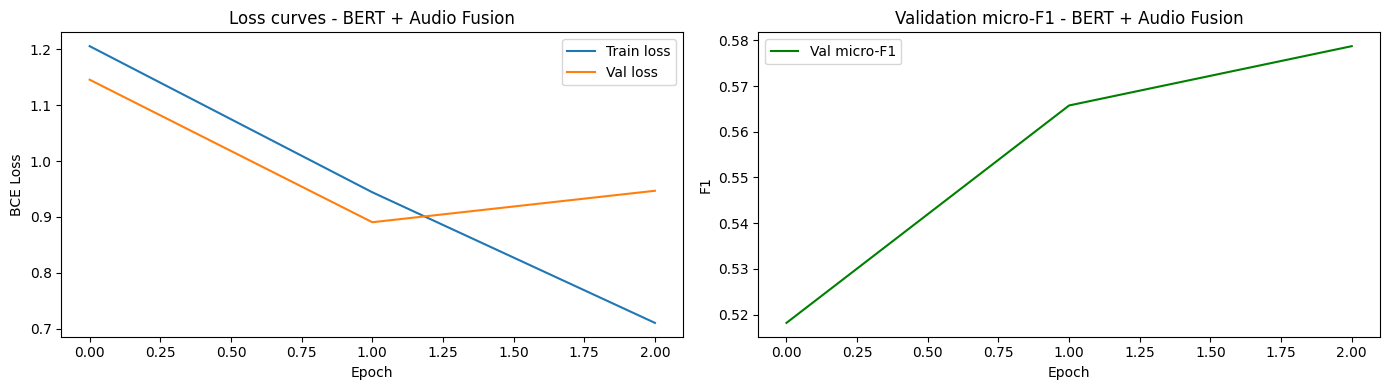

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(bert_history['train_loss'], label='Train loss')
axes[0].plot(bert_history['val_loss'], label='Val loss')
axes[0].set_title('Loss curves - BERT + Audio Fusion')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(bert_history['val_f1_micro'], color='green', label='Val micro-F1')
axes[1].set_title('Validation micro-F1 - BERT + Audio Fusion')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9.6 BERT-Only (Evaluating Audio Impact)

In [ ]:
bert_only_model = BertMoodClassifier(use_audio=False).to(DEVICE)

only_history, best_val_f1_only = train_bert_model(
    bert_only_model, bert_train_loader, bert_val_loader,
    use_audio=False, ckpt_dir=ckpt_dir_bert_only,
    lr=3.13e-05, weight_decay=1.15e-05, threshold=0.49,
    epochs=3
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


No checkpoint found - training from scratch.


Epoch 01/3 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 01/3 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

...

Epoch 02/3 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 02/3 | train_loss: 1.1011 | val_loss: 1.0944 | val_micro-F1: 0.4721 | New best! Saved best_model.pt


Epoch 03/3 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 03/3 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 03/3 | train_loss: 0.9078 | val_loss: 1.2220 | val_micro-F1: 0.5123 | New best! Saved best_model.pt

Best validation micro-F1: 0.5123
Loaded best model weights from /content/drive/MyDrive/deep_learning/checkpoints_bert_only/best_model.pt


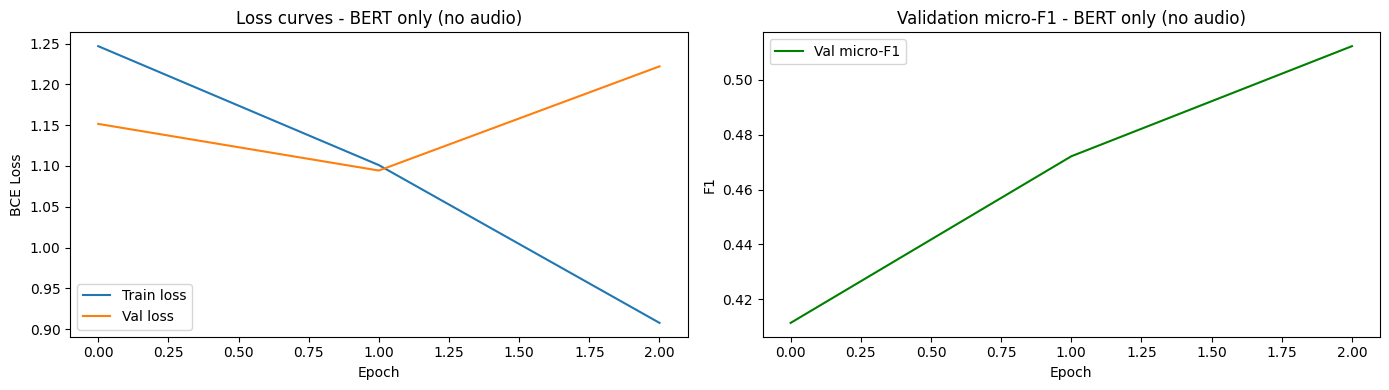

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(only_history['train_loss'], label='Train loss')
axes[0].plot(only_history['val_loss'], label='Val loss')
axes[0].set_title('Loss curves - BERT only (no audio)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(only_history['val_f1_micro'], color='green', label='Val micro-F1')
axes[1].set_title('Validation micro-F1 - BERT only (no audio)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9.6 Continuing Training for the Better Model (BERT + Audio)

In [ ]:
bert_history, best_val_f1_bert = train_bert_model(
    bert_fusion_model, bert_train_loader, bert_val_loader,
    use_audio=True, ckpt_dir=ckpt_dir_bert_fusion,
    lr=3.13e-05, weight_decay=1.15e-05, threshold=0.49,
    epochs=5
)

Found checkpoint: /content/drive/MyDrive/deep_learning/last_checkpoint.pt - resuming training...
Resuming from epoch 4 | Best val micro-F1 so far: 0.5787


Epoch 04/5 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 04/5 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 04/5 | train_loss: 0.6332 | val_loss: 1.0717 | val_micro-F1: 0.6000 | New best! Saved best_model.pt


Epoch 05/5 [train]:   0%|          | 0/10000 [00:00<?, ?it/s]

Epoch 05/5 [val]  :   0%|          | 0/1250 [00:00<?, ?it/s]

Epoch 05/5 | train_loss: 0.4663 | val_loss: 1.3546 | val_micro-F1: 0.5762 | Checkpoint saved

Best validation micro-F1: 0.6000
Loaded best model weights from /content/drive/MyDrive/deep_learning/best_model.pt


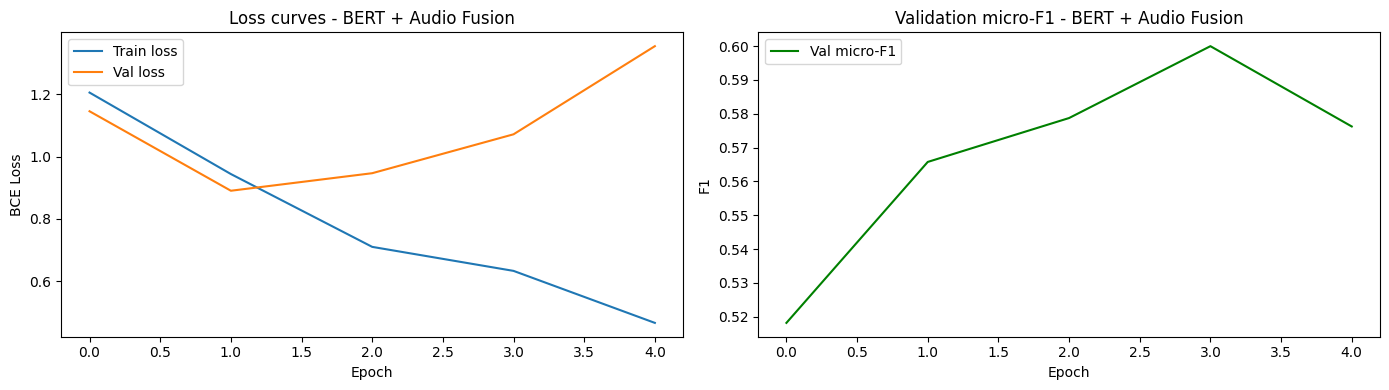

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(bert_history['train_loss'], label='Train loss')
axes[0].plot(bert_history['val_loss'], label='Val loss')
axes[0].set_title('Loss curves - BERT + Audio Fusion')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()

axes[1].plot(bert_history['val_f1_micro'], color='green', label='Val micro-F1')
axes[1].set_title('Validation micro-F1 - BERT + Audio Fusion')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].legend()

plt.tight_layout()
plt.show()

Czwarta epoka okazała się najlepsza z wynikiem micro-F1: 0.6000

## 9.7 Evaluation on the Test Set and Sample Predictions

In [ ]:
BEST_CKPT_PATH  = ckpt_dir_bert_fusion
bert_fusion_model.load_state_dict(torch.load(BEST_CKPT_PATH, map_location=DEVICE))
bert_fusion_model.eval()

all_preds_bert, all_labels_test_bert = [], []

with torch.no_grad():
    for batch in tqdm(bert_test_loader, desc='Evaluating'):
        ids   = batch['input_ids'].to(DEVICE)
        mask  = batch['attention_mask'].to(DEVICE)
        audio = batch['audio'].to(DEVICE)

        logits = bert_fusion_model(ids, mask, audio)
        preds  = (torch.sigmoid(logits) > 0.49).cpu().numpy()
        all_preds_bert.append(preds)
        all_labels_test_bert.append(batch['labels'].numpy())

all_preds_bert       = np.vstack(all_preds_bert)
all_labels_test_bert = np.vstack(all_labels_test_bert)

f1_micro_bert = f1_score(all_labels_test_bert, all_preds_bert, average='micro', zero_division=0)
f1_macro_bert = f1_score(all_labels_test_bert, all_preds_bert, average='macro', zero_division=0)

print(f'[BERT + Audio Fusion] Test micro-F1: {f1_micro_bert:.4f}')
print(f'[BERT + Audio Fusion] Test macro-F1: {f1_macro_bert:.4f}')
print()
print(classification_report(all_labels_test_bert, all_preds_bert, target_names=target_columns, zero_division=0))

Evaluating:   0%|          | 0/1250 [00:00<?, ?it/s]

[BERT + Audio Fusion] Test micro-F1: 0.5975
[BERT + Audio Fusion] Test macro-F1: 0.4631

                                precision    recall  f1-score   support

                         anger       0.66      0.78      0.72      1007
                          fear       0.54      0.70      0.61       277
                           joy       0.76      0.84      0.80      1849
                          love       0.58      0.74      0.65       259
                       sadness       0.77      0.80      0.78      1556
                      surprise       0.45      0.67      0.54        51
                Good for Party       0.20      0.37      0.26       311
           Good for Work/Study       0.39      0.74      0.51       413
Good for Relaxation/Meditation       0.24      0.41      0.30       181
             Good for Exercise       0.50      0.76      0.60       959
              Good for Running       0.25      0.48      0.33       280
      Good for Yoga/Stretching       0.20     

In [35]:
import random

sample_indices = random.sample(range(len(X_test)), 5)

bert_fusion_model.eval()
with torch.no_grad():
    for idx in sample_indices:
        text  = X_test['cleaned_text'].iloc[idx]
        audio = torch.tensor(A_test[idx], dtype=torch.float32).unsqueeze(0).to(DEVICE)
        true_labels = [target_columns[i] for i, v in enumerate(y_test.iloc[idx]) if v == 1]

        enc  = tokenizer(text, max_length=BERT_MAX_LEN, padding='max_length',
                         truncation=True, return_tensors='pt')
        ids  = enc['input_ids'].to(DEVICE)
        mask = enc['attention_mask'].to(DEVICE)

        logits = bert_fusion_model(ids, mask, audio)
        preds  = (torch.sigmoid(logits) > 0.49).cpu().numpy()[0]
        pred_labels = [target_columns[i] for i, v in enumerate(preds) if v]

        print(f"Lyrics: {text[:100]}...")
        print(f"True labels: {true_labels}")
        print(f"Predicted labels: {pred_labels}")
        print()

Lyrics: convict convict convict youngyoungyoungyoungbloodz youngyoungyoungyoungbloodz thatththatthatththat t...
True labels: ['anger']
Predicted labels: ['anger', 'Good for Exercise', 'Good for Running']

Lyrics: i wish theres someone i could see cause im the one whos needy journeying away i used to have a radio...
True labels: ['sadness', 'Good for Exercise', 'Good for Running']
Predicted labels: ['sadness', 'Good for Exercise']

Lyrics: another rebel runs against the grain a loner is born hes filled with anguish deep within hes dying e...
True labels: ['sadness']
Predicted labels: ['sadness']

Lyrics: o rtf girl are you stone let me be your china gnome play me on your gramophone and bury me in your g...
True labels: ['joy', 'Good for Party', 'Good for Exercise']
Predicted labels: ['joy']

Lyrics: didnt take time to tell all our love was in decline you were fresh off the shelf but you lacked the ...
True labels: ['joy']
Predicted labels: ['anger', 'Good for Work/Study', 'Good for Morn